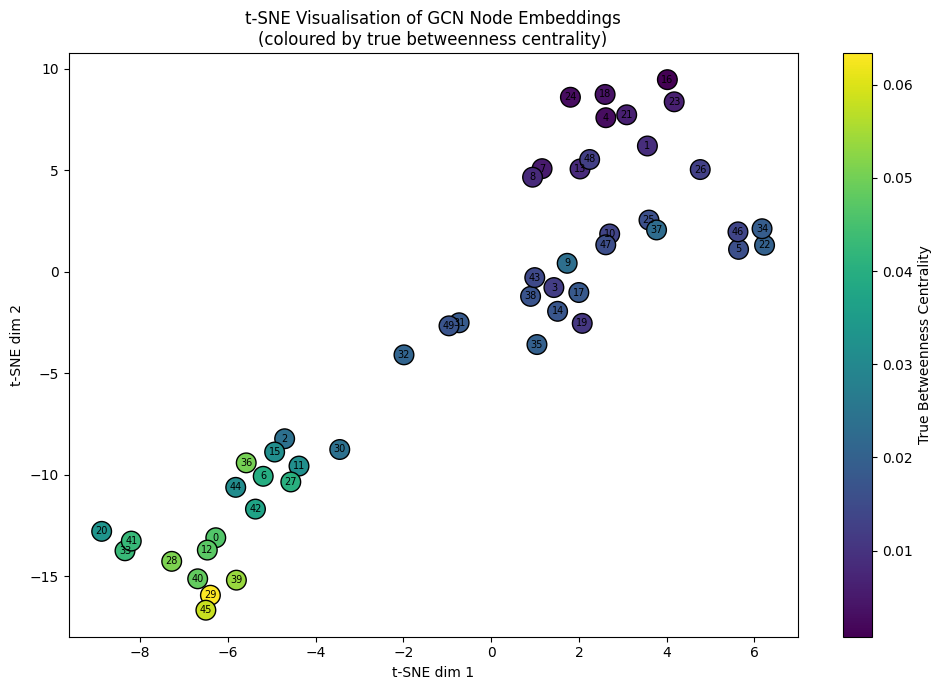

Saved week4_embedding_tsne.png

Top 5 highest betweenness nodes: [36 28 39 45 29]
Top 5 lowest betweenness nodes: [16  4 24 18  7]


In [1]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import networkx as nx

embeddings = torch.load('../results/gcn_embeddings.pt', weights_only=False).detach().numpy()
data = torch.load('../results/graph_data.pt', weights_only=False)
true_betweenness = data.x[:, 1].numpy()

# t-SNE projection to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=true_betweenness, cmap='viridis',
                      s=200, edgecolors='black')
plt.colorbar(scatter, label='True Betweenness Centrality')
plt.title("t-SNE Visualisation of GCN Node Embeddings\n(coloured by true betweenness centrality)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")

for i in range(len(embeddings_2d)):
    plt.annotate(str(i), (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                fontsize=7, ha='center', va='center')

plt.tight_layout()
plt.savefig("../results/week4_embedding_tsne.png", dpi=150)
plt.show()
print("Saved week4_embedding_tsne.png")

# Check correlation between embedding distance and betweenness similarity
print("\nTop 5 highest betweenness nodes:", np.argsort(true_betweenness)[-5:])
print("Top 5 lowest betweenness nodes:", np.argsort(true_betweenness)[:5])